In [48]:
import numpy as np
import pandas as pd

### Load DataSet

In [49]:
df = pd.read_csv(
    'fra.txt',
    sep = '\t',
    header = None,
    usecols=[0, 1],
    names = ['English', 'French']
)

df = df.iloc[:10000]
df['French'] = df['French'].apply(lambda x: "<start>" + x + "<end>")


In [50]:
df.head()

,English,French
0,Go.,<start>Va !<end>
1,Go.,<start>Marche.<end>
2,Go.,<start>En route !<end>
3,Go.,<start>Bouge !<end>
4,Hi.,<start>Salut !<end>


### Train Test SPlit

In [51]:
english_sentence = df['English'].values
french_sentence = df['French'].values

## Tokenization

In [52]:
from tensorflow.keras.preprocessing.text import Tokenizer

# English Tokenizer
eng_tokenizer = Tokenizer()
eng_tokenizer.fit_on_texts(english_sentence)
encoder_input = eng_tokenizer.texts_to_sequences(english_sentence)  # Now Assign Numbers Sentence by Sentence

# French Tokenizer
fre_tokenizer = Tokenizer(filters = '')
fre_tokenizer.fit_on_texts(french_sentence)
decoder_input = fre_tokenizer.texts_to_sequences(french_sentence)   # Now Assign Numbers Sentence by Sentence

### Add Padding

In [53]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

encoder_input = pad_sequences(encoder_input, padding = 'post')
decoder_input = pad_sequences(decoder_input, padding = 'post')

### Check Vocabulary Size

In [54]:
english_vocab_size = len(eng_tokenizer.word_index) +1
french_vocab_size = len(fre_tokenizer.word_index) + 1
print("English Size : ", english_vocab_size)
print("French Size : ", french_vocab_size)

English Size :  2035
French Size :  5799


### Maximum Length

In [55]:
max_encoder = encoder_input.shape[1]
max_decoder = decoder_input.shape[1]

print("Max Encoder : ", max_encoder)
print("Max Decoder : ", max_decoder)

Max Encoder :  4
Max Decoder :  10


In [56]:
decoder_target = np.zeros_like(decoder_input)
decoder_target [:, :-1] = decoder_input[:, 1:]

In [57]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense

### Encoder Archeticture

In [58]:
model = Sequential()
encoder_inputs = Input(shape=(max_encoder,))
encoder_embedding = Embedding(english_vocab_size, 100)(encoder_inputs)
encoder_output, state_h, state_c = LSTM(150, return_state=True)(encoder_embedding)

### Decoder Archeticture

In [59]:
model1 = Sequential()

decoder_inputs = Input(shape=(max_decoder,))
decoder_embedding = Embedding(french_vocab_size, 100)(decoder_inputs)
decoder_lstm = LSTM(150, return_sequences=True, return_state=True)
decoder_output, _, _ = decoder_lstm(decoder_embedding, initial_state=[state_h, state_c])

decoder_output = Dense(french_vocab_size, activation='softmax')(decoder_output)

### Complete Model

In [60]:

# Complete Model
complete_model = Model(
    [encoder_inputs, decoder_inputs],
    decoder_output
)

complete_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_7       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_6         │ (None, 4, 100)    │    203,500 │ input_layer_6[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_7         │ (None, 10, 100)   │    579,900 │ input_layer_7[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_6 (LSTM)       │ [(None, 150),     │    150,600 │ embedding_6[0][0] │
│                     │ (None, 150),      │            │                   │
│                     │ (None, 150)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_7 (LSTM)       │ [(None, 10, 150), │    150,600 │ embedding_7[0][0… │
│                     │ (None, 150),      │            │ lstm_6[0][1],     │
│                     │ (None, 150)]      │            │ lstm_6[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 10, 5799)  │    875,649 │ lstm_7[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,960,249 (7.48 MB)

 Trainable params: 1,960,249 (7.48 MB)

 Non-trainable params: 0 (0.00 B)

In [61]:
complete_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [62]:
decoder_target = np.expand_dims(decoder_target, -1)

In [63]:
history = complete_model.fit([encoder_input, decoder_input], decoder_target, epochs=20, batch_size=32, validation_split=0.2)

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 46s 166ms/step - accuracy: 0.7656 - loss: 3.5334 - val_accuracy: 0.7537 - val_loss: 1.8464
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 40s 159ms/step - accuracy: 0.7912 - loss: 1.4305 - val_accuracy: 0.7632 - val_loss: 1.7730
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 41s 157ms/step - accuracy: 0.7973 - loss: 1.3187 - val_accuracy: 0.7707 - val_loss: 1.7151
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 43s 172ms/step - accuracy: 0.8196 - loss: 1.2036 - val_accuracy: 0.7789 - val_loss: 1.6621
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 43s 171ms/step - accuracy: 0.8316 - loss: 1.1114 - val_accuracy: 0.7807 - val_loss: 1.6416
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 77s 150ms/step - accuracy: 0.8375 - loss: 1.0359 - val_accuracy: 0.7856 - val_loss: 1.6235
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 36s 143ms/step - accuracy: 0.8458 - loss: 0.9552 - val_accuracy: 0.7869 - val_loss: 1.6287
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 33s 132ms/step - accuracy: 0.8528 - loss: 0

### Loss

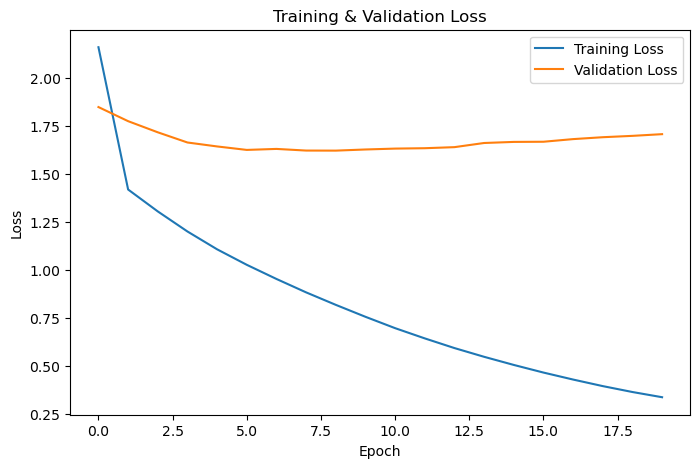

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.show()

### Accuracy

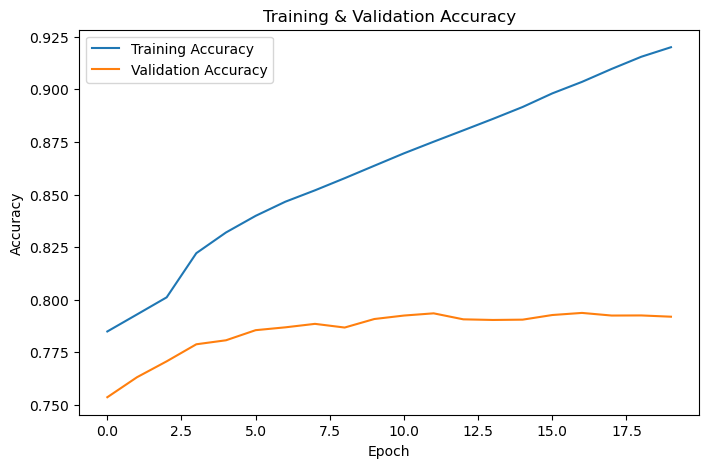

In [65]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy")
plt.legend()
plt.show()

In [ ]:
sentence = "I am a student"

# Convert text to sequence
sequence = tokenizer.texts_to_sequences([sentence])

# Pad sequence
sequence = pad_sequences(sequence, maxlen=max_encoder, padding='post')

# Predict
prediction = model.predict(sequence)
  
print(prediction)

NameError: name 'tokenizer' is not defined